# 📊 Final Project Evaluation: Political Art Nights (2025/2026) - Association CAMBIO

* **Goal:** Analyze overall participant satisfaction and loyalty across monthly events using collected survey feedback.

### 🛠️ Scope & Methodology
* **Database:** PostgreSQL (`events`, `feedbacks`, `answers`, `indicators`, `scales`, `channels`)
* **Time Period:** 2025/2026 Season
* **Key Performance Indicators (KPIs):** Response Rate (n/N), Average Score (out of 5), and Top-Box Rate (Fidelity)

In [ ]:
!pip install psycopg2-binary python-dotenv

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sqlalchemy import create_engine
import os 
from dotenv import load_dotenv

sns.set_theme(style="whitegrid") 
plt.rcParams["font.sans-serif"] = "DejaVu Sans"  

In [ ]:
#technique pour changer le nom du fichier .env et le rendre visible ou non (avec le vrai nom .env)
if os.path.exists("env.txt"):
    os.rename("env.txt", ".env")
    print("Fichier renommé en env.txt ! Vous pouvez l'ouvrir dans le navigateur de fichiers de Jupyter.")

In [ ]:
load_dotenv()

DB_USER = os.getenv("POSTGRES_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")


db_url = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(db_url)

### Overview of all the event of the year


In [13]:
query = "SELECT event_name, event_location, event_date, nb_participants, theme FROM events;"
df = pd.read_sql(query, con=engine)
df.columns = ["Event", "Location", "Date", "Participants number", "Theme"]
df

,Event,Location,Date,Participants number,Theme
0,Cultivating hopeful narratives,Kukulida,2025-10-23,22,ecology
1,Who made your clothes,Cafe Peckerl,2025-11-28,32,ecology
2,Do it yourself,Weltclub,2025-12-11,36,ecology
3,There will be soup,The hole of fame,2026-01-23,42,human right
4,Improv poetry night,Stadtteilhaus Neustadt,2026-02-12,15,human right
5,Being in migration,Stadtteilhaus Neustadt,2026-04-16,19,human right
6,The climate mapping,Weltclub,2026-05-28,17,ecology
7,Sustainable bike tour in Dresden,Outside,2026-06-18,17,ecology
8,Performing gender,The hole of fame,2026-07-02,17,human right
9,Circles of care,GHE8 Kulturzentrum,2026-03-19,12,human right


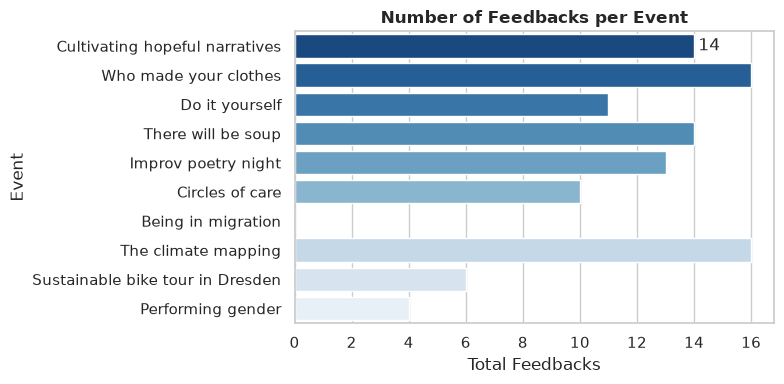

In [14]:
query = """
    SELECT e.event_name, COUNT(f.feedback_id) as total_feedbacks 
    FROM events as e LEFT JOIN feedbacks as f on e.event_id = f.event_id
    GROUP BY e.event_id, e.event_name
    ORDER BY e.event_id;
    ;
"""
df = pd.read_sql(query, con=engine)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=df, x="total_feedbacks", y="event_name", hue="event_name",  
    legend=False, palette="Blues_r"
)

plt.title("Number of Feedbacks per Event", fontsize=12, fontweight="bold")
plt.xlabel("Total Feedbacks")
plt.ylabel("Event")


ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

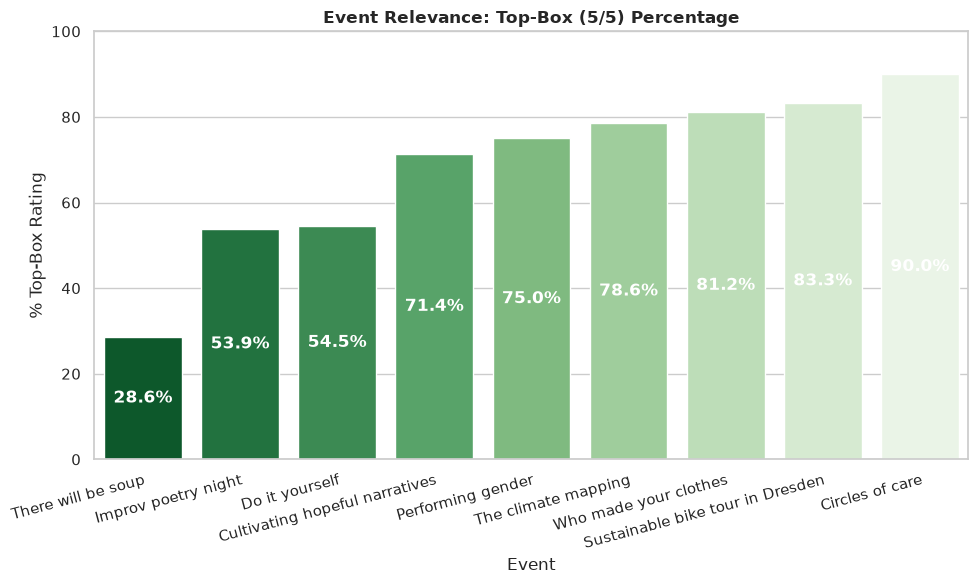

In [15]:
query2 = """
    SELECT e.event_name, COUNT(a.answer_id) FILTER (WHERE a.answer_score = 5) AS total_best_answers, 
    count(a.answer_id) AS total_answers,
    ROUND(
        100.0 * COUNT(a.answer_id) FILTER (WHERE a.answer_score = 5)/COUNT(a.answer_id), 
    2) AS percentage_best_answer
    FROM events as e JOIN feedbacks as f on e.event_id = f.event_id
    JOIN answers as a on a.feedback_id = f.feedback_id
    WHERE a.indicator_id = 3 AND a.answer_score IS NOT NULL
    GROUP BY e.event_name, e.event_id
    ORDER BY percentage_best_answer ASC;
"""
df2 = pd.read_sql(query2, con=engine)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df2, x="event_name", y="percentage_best_answer",
    hue="event_name",  
    legend=False,
    palette="Greens_r"
)

plt.title(
    "Event Relevance: Top-Box (5/5) Percentage", fontsize=12, fontweight="bold"
)
plt.ylabel("% Top-Box Rating")
plt.xlabel("Event")
plt.ylim(0, 100) 

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        color="white",
        fontweight="bold",
    )
plt.xticks(rotation=15, ha="right", rotation_mode="anchor")  

plt.tight_layout()
plt.show()


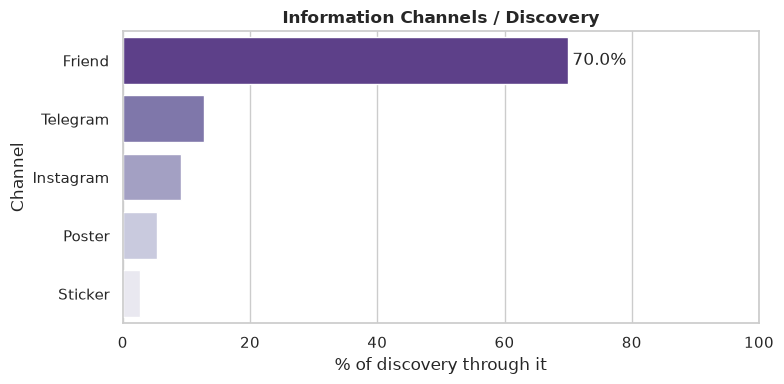

In [16]:

query = """
    SELECT c.channel_name, COUNT(a.channel_id), 
    ROUND(
       100.0 * COUNT(a.channel_id)/SUM(COUNT(a.channel_id)) OVER (), 
       2) AS percentage_of_selection
    FROM answers AS a JOIN channels AS c ON a.channel_id = c.channel_id
    WHERE a.indicator_id = 10 and a.channel_id IS NOT NULL
    GROUP BY c.channel_id;
"""

df = pd.read_sql(query, con=engine)
df

plt.figure(figsize=(8, 4))

df = df.sort_values(by="percentage_of_selection", ascending=False)

ax = sns.barplot(
    data=df, x="percentage_of_selection", y="channel_name", hue="channel_name",  
    legend=False, palette="Purples_r"
)

plt.title("Information Channels / Discovery", fontsize=12, fontweight="bold")
plt.xlabel("% of discovery through it")
plt.ylabel("Channel")
plt.xlim(0, 100)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


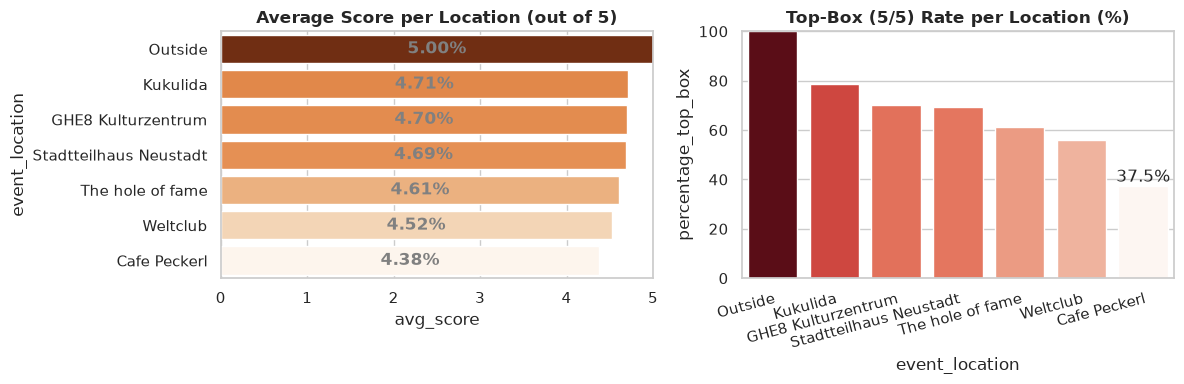

In [17]:
query = """
    WITH nb_participitants_location AS (
        SELECT 
            e.event_location,
            SUM(e.nb_participants) AS total_participants
        FROM events as e
        WHERE e.event_id != 7
        GROUP BY e.event_location
    )
    SELECT e.event_location, ROUND(AVG(a.answer_score), 2) AS avg_score,
    ROUND(100.0 * COUNT(a.answer_id)/lc.total_participants, 2) AS percentage_of_answer,
    ROUND(100.0 * COUNT(a.answer_score) FILTER (WHERE a.answer_score = 5)/COUNT(a.answer_id) ,2) AS percentage_top_box
    
    FROM events AS e JOIN feedbacks AS f on e.event_id = f.event_id 
    JOIN answers AS a on f.feedback_id = a.feedback_id
    JOIN nb_participitants_location AS lc ON e.event_location = lc.event_location
    
    WHERE a.indicator_id = 9 AND e.event_id != 7 AND a.answer_score IS NOT NULL
    GROUP BY e.event_location, lc.total_participants
    ORDER BY avg_score DESC;
"""
df = pd.read_sql(query, con=engine)
df

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=df,
    x="avg_score",
    y="event_location",
    ax=ax1,
    hue="avg_score",  
    legend=False,
    palette="Oranges",
)
ax1.set_title("Average Score per Location (out of 5)", fontweight="bold")
ax1.set_xlim(0, 5)
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt="%.2f%%",
        label_type="center",
        color="grey",
        fontweight="bold",
    )

sns.barplot(
    data=df,
    x="event_location",
    y="percentage_top_box",
    hue="percentage_top_box",  
    legend=False,
    ax=ax2,
    palette="Reds",
)
ax2.set_title("Top-Box (5/5) Rate per Location (%)", fontweight="bold")
ax2.set_ylim(0, 100)
ax2.bar_label(ax2.containers[0], fmt="%.1f%%")
plt.xticks(rotation=15, ha="right", rotation_mode="anchor")

plt.tight_layout()
plt.show()

event,% of answers to the question
There will be soup,30.950000
Performing gender,23.530000
Circles of care,83.330000
Who made your clothes,46.880000
Sustainable bike tour in Dresden,35.290000
Do it yourself,30.560000
Cultivating hopeful narratives,63.640000
Improv poetry night,86.670000
The climate mapping,82.350000


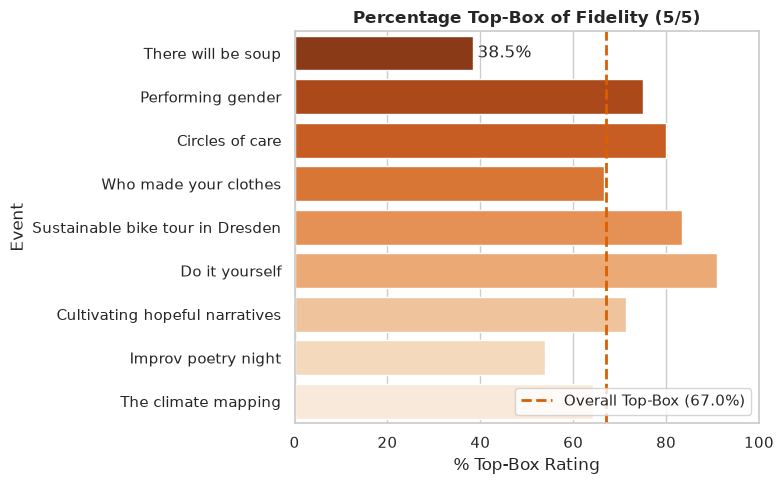

In [18]:
query = """
    SELECT e.event_name, ROUND(100.0 * COUNT(a.answer_id)/e.nb_participants, 2) AS percentage_of_answer,
    ROUND(100.0 * COUNT(a.answer_score) FILTER (WHERE a.answer_score = 5) /COUNT(a.answer_score), 2) AS percentage_top_box,
    COUNT(a.answer_score) AS total_responses,
    COUNT(a.answer_score) FILTER (WHERE a.answer_score = 5) as top_box_responses
    FROM events AS e JOIN feedbacks AS f on e.event_id = f.event_id
    JOIN answers AS a on f.feedback_id = a.feedback_id
    WHERE a.indicator_id = 11
    GROUP BY e.event_name, e.event_id, e.nb_participants;
"""

df = pd.read_sql(query, con=engine)

overall_top_box = round((100 *
    df["top_box_responses"].sum()) / df["total_responses"].sum(), 2)

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=df,
    x="percentage_top_box",
    y="event_name",
    ax=ax1,
    hue="event_name",  
    legend=False,
    palette="Oranges_r",
)

ax1.axvline(
    x=overall_top_box,
    color="#d95f02",  
    linestyle="--",  
    linewidth=2,
    label=f"Overall Top-Box ({overall_top_box:.1f}%)",
)

ax1.set_title("Percentage Top-Box of Fidelity (5/5)", fontweight="bold")
ax1.set_xlabel("% Top-Box Rating")
ax1.set_ylabel("Event")
ax1.set_xlim(0, 100)  
ax1.legend(loc="lower right")  

ax1.bar_label(ax1.containers[0], fmt="%.1f%%", padding=3)

tableau_reponse = df[["event_name", "percentage_of_answer"]].copy()

tableau_reponse.columns = ["event", "% of answers to the question"]

display(tableau_reponse.style.format({"% de Réponse à la Question": "{:.1f}%"}).hide(axis="index"))
plt.tight_layout()
plt.show()